## Cassidy's Notebook For EDA

### Exploratory Data Analysis (EDA): 
- Including: distribution analysis of key features (visualize and discuss patterns, skewness, etc.)
- Correlation analysis between features and target variables
- Identification of potential relationships and insights
- Feature importance assessment
- Time-based patterns or trends (if applicable)

### Visualization requirements: 
- Include multiple detailed plots that effectively communicate your data insights
- Ensure all plots have properly labeled x and y axes
- Include descriptive titles
- Add legends where appropriate
- Consider using multiple plot types (histograms, scatter plots, box plots, heatmaps, etc.) to highlight different aspects of your data
- Accompany each visualization with interpretations of what the patterns reveal

### Load Data Processed Data

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
# Load training data for EDA
X_train = pd.read_csv('cleaned_x_train.csv')
Y_train = pd.read_csv('cleaned_y_train.csv')

print(X_train.columns)
print(Y_train.columns)

Index(['ACEDEPRS', 'ACEDRINK', 'ACEDRUGS', 'ACEPRISN', 'ACEDIVRC', 'ACEPUNCH',
       'ACEHURT1', 'ACESWEAR', 'ACETOUCH', 'ACETTHEM', 'ACEADSAF', 'ACEADNED',
       '_EDUCAG', '_AGE80', '_SEX', 'MENTHLTH', 'PHYSHLTH', '_SMOKER3',
       'race_2.0', 'race_3.0', 'race_4.0', 'race_5.0', 'ACE_SCORE'],
      dtype='object')
Index(['risky_drinking'], dtype='object')


### EDA

/var/folders/2q/h7d9kcps26n292mk9v98nbfm0000gn/T/ipykernel_99777/4019065529.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 1))


Text(0, 0.5, 'Count')

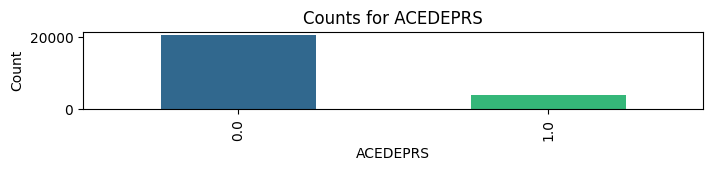

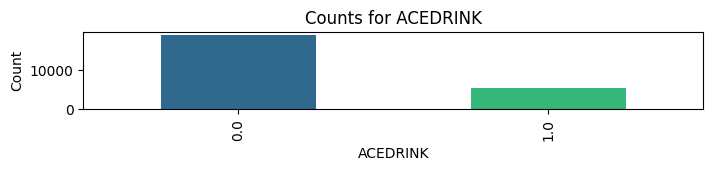

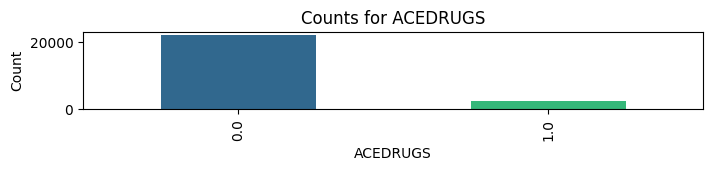

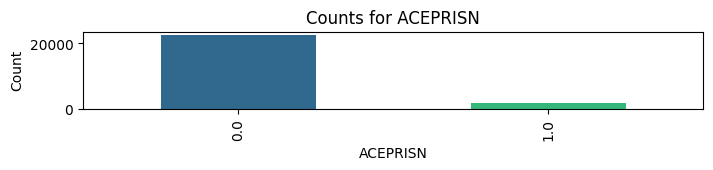

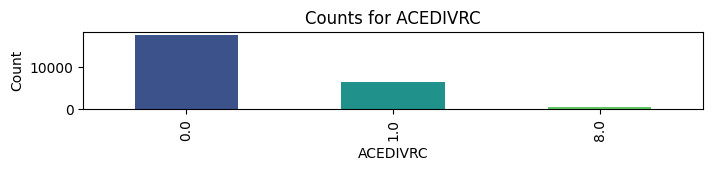

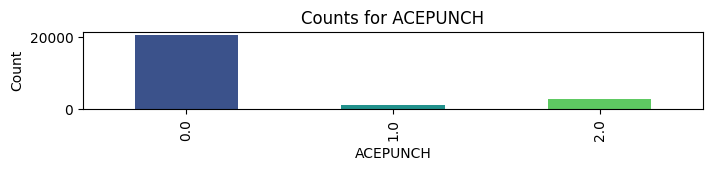

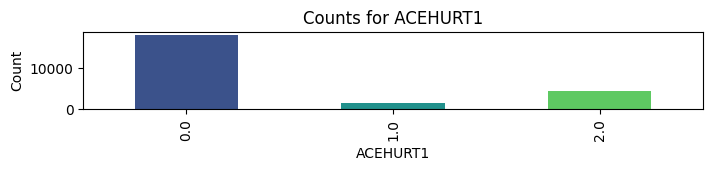

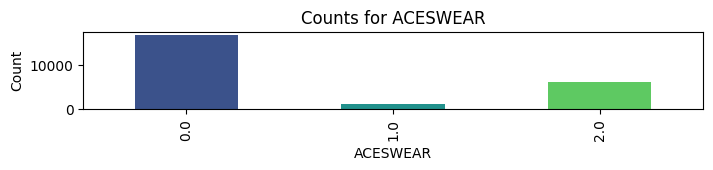

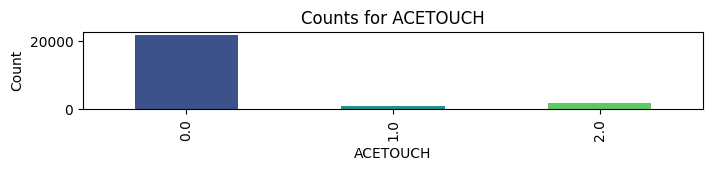

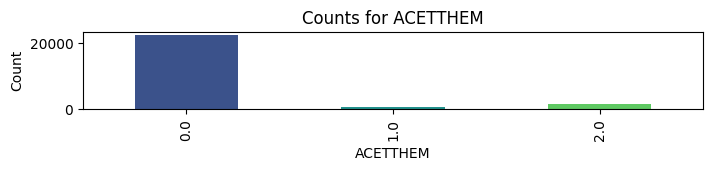

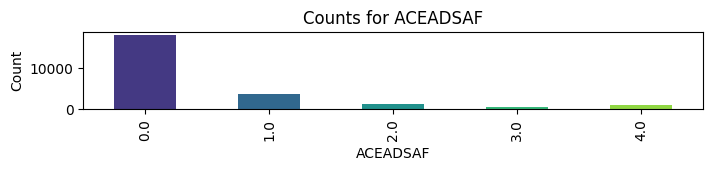

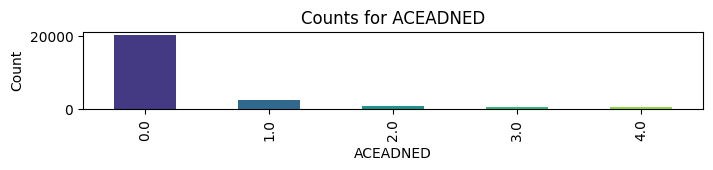

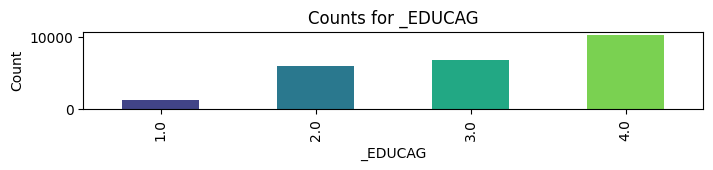

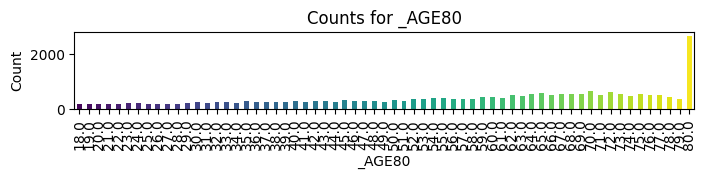

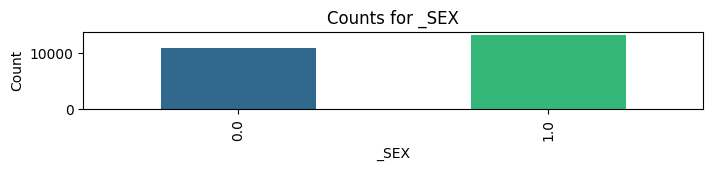

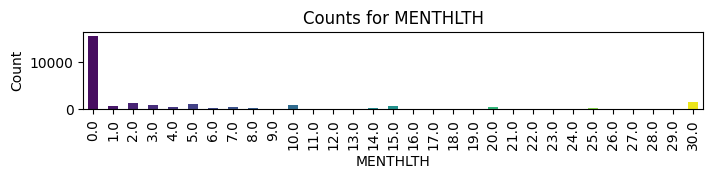

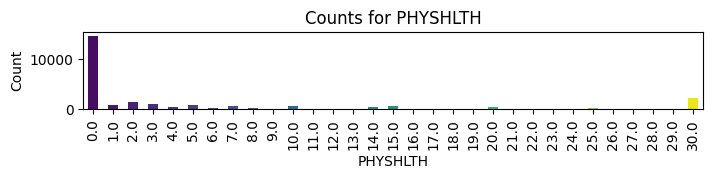

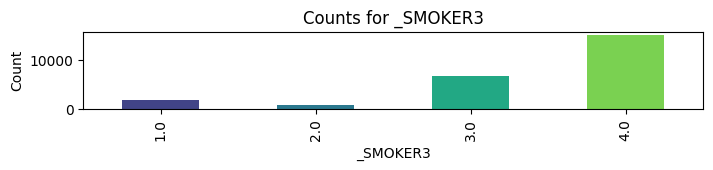

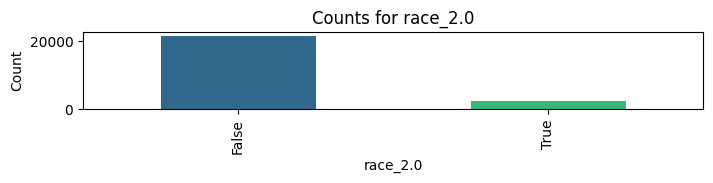

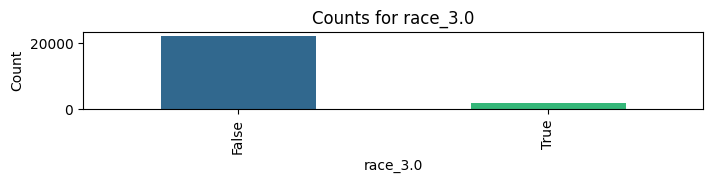

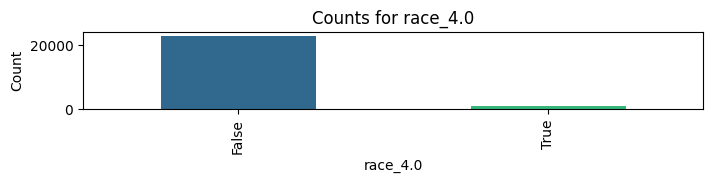

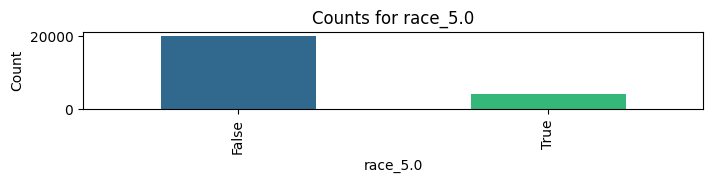

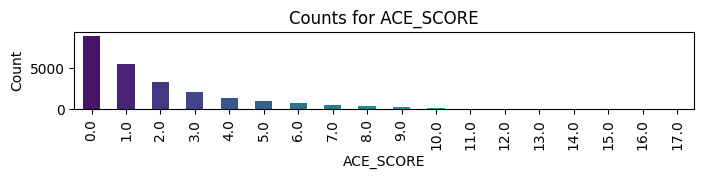

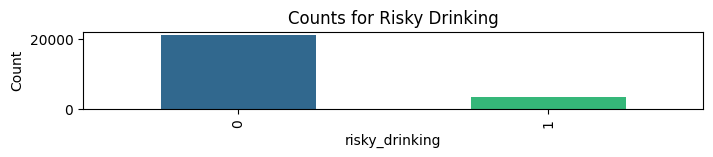

In [3]:
for col in X_train.columns:
    plt.figure(figsize=(8, 1))
    counts = X_train[col].value_counts().sort_index()
    colors = sns.color_palette("viridis", len(counts))
    counts.plot(kind='bar', color=colors)
    plt.title(f"Counts for {col}")
    plt.ylabel("Count")

plt.figure(figsize=(8, 1))
colors = sns.color_palette("viridis", len(Y_train['risky_drinking'].value_counts()))
Y_train['risky_drinking'].value_counts().plot(kind='bar', color=colors)
plt.title(f"Counts for Risky Drinking")
plt.ylabel("Count")

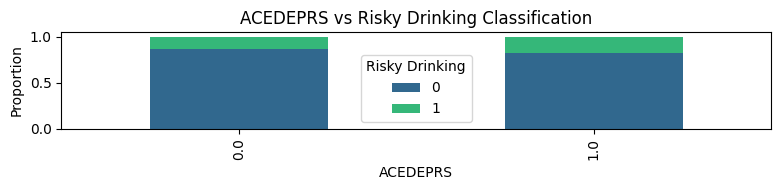

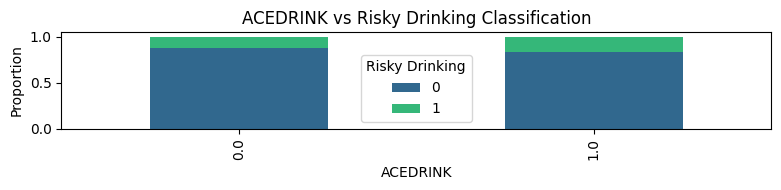

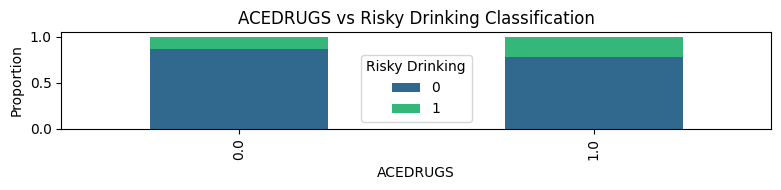

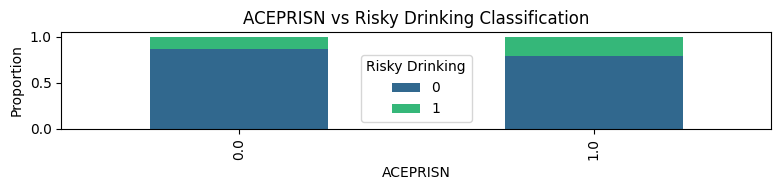

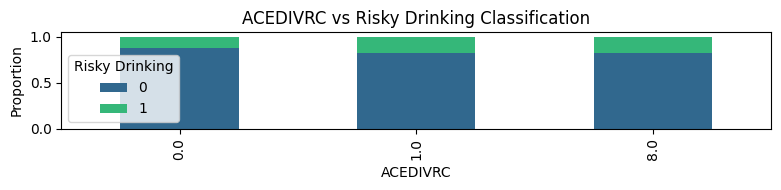

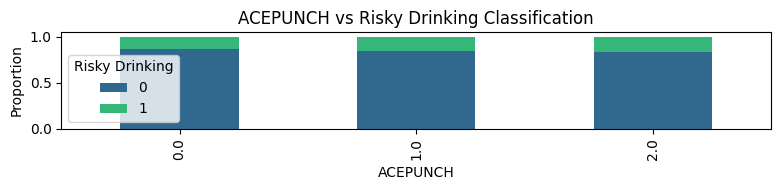

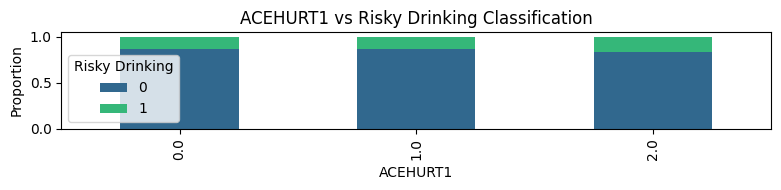

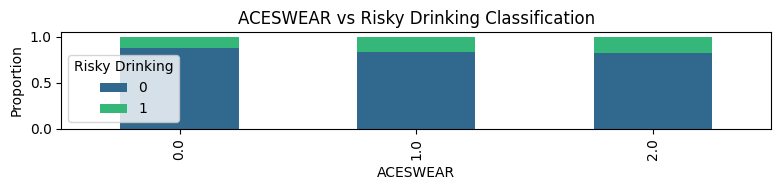

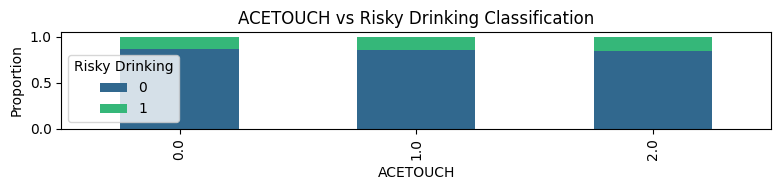

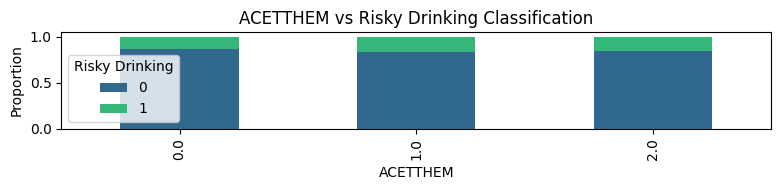

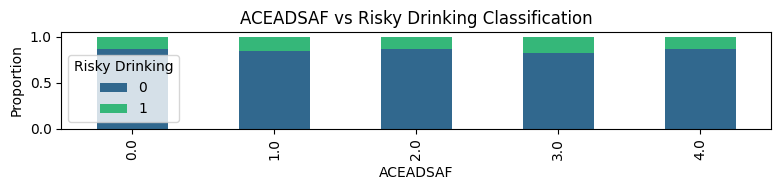

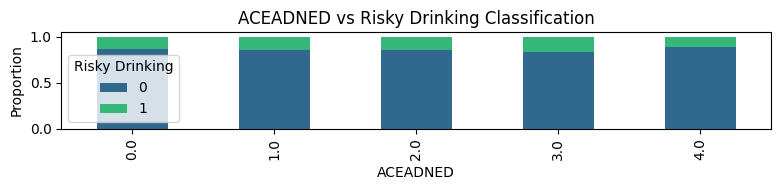

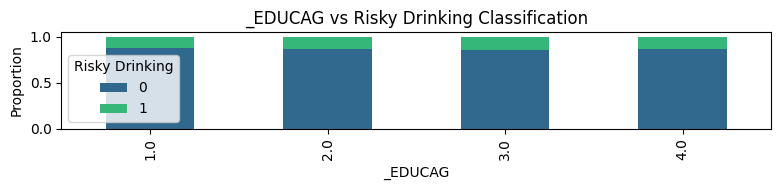

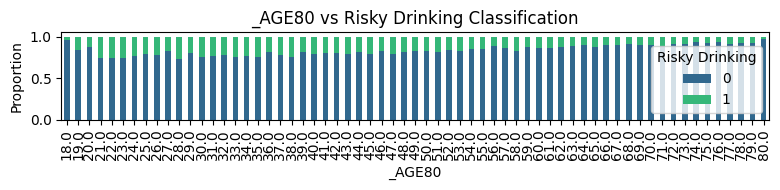

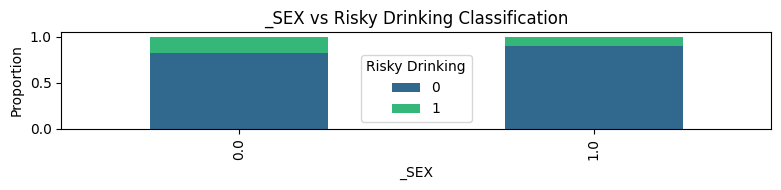

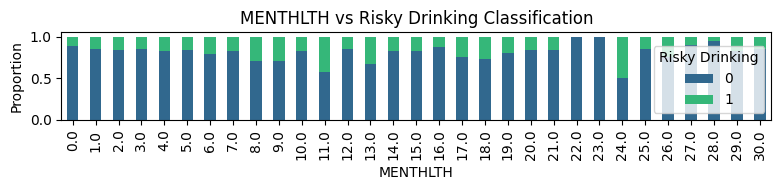

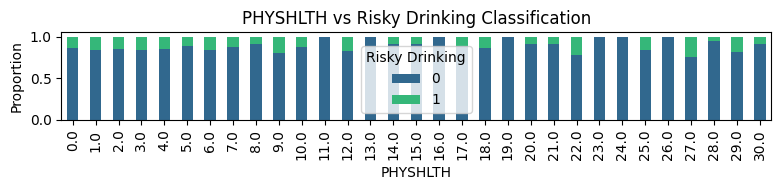

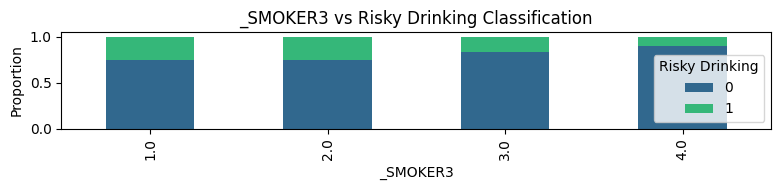

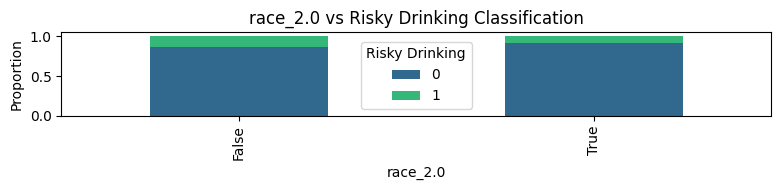

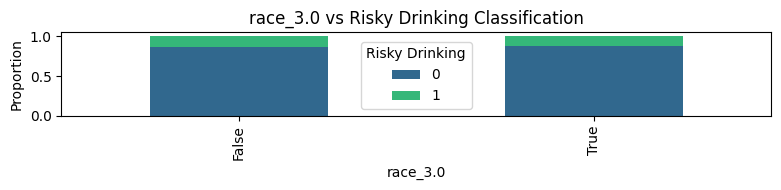

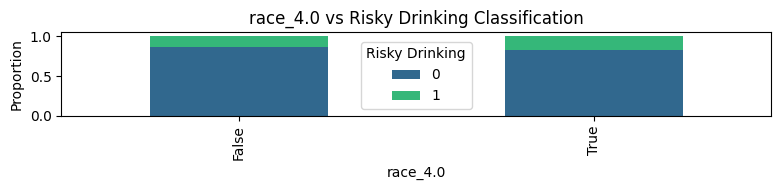

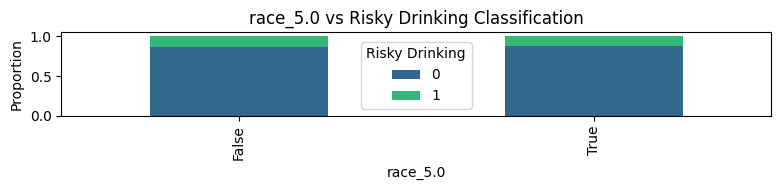

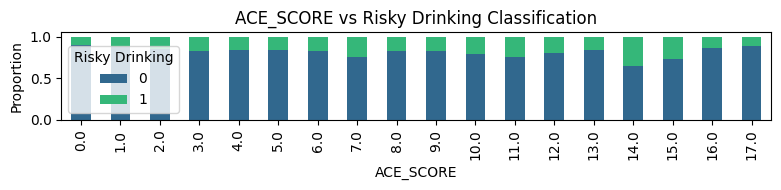

In [4]:
for col in X_train.columns:
    temp = pd.crosstab(X_train[col], Y_train['risky_drinking'], normalize='index')
    order = sorted(X_train[col].dropna().unique())
    temp = temp.reindex(order)
    colors = sns.color_palette("viridis", n_colors=len(temp.columns))
    temp.plot(kind='bar', stacked=True, figsize=(8, 2), color=colors)
    plt.title(f"{col} vs Risky Drinking Classification")
    plt.ylabel("Proportion")
    plt.xlabel(col)
    plt.legend(title="Risky Drinking")
    plt.tight_layout()
    plt.show()

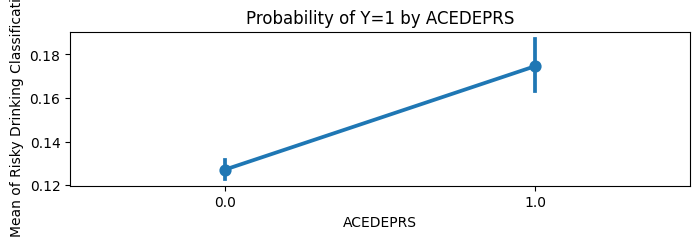

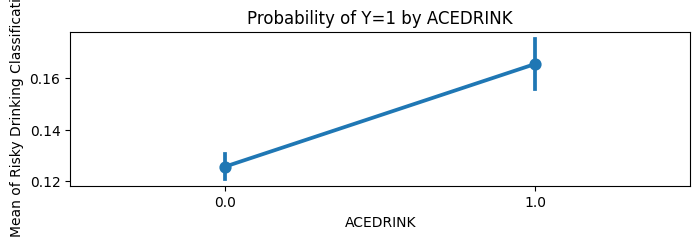

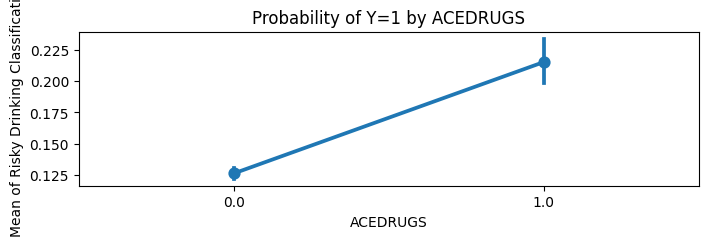

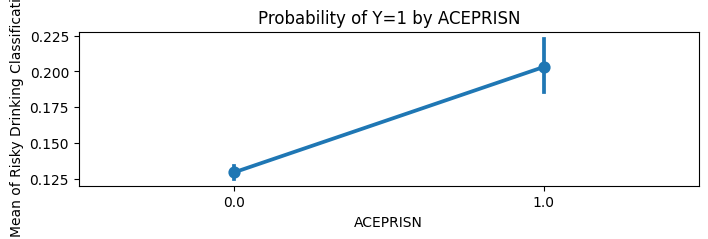

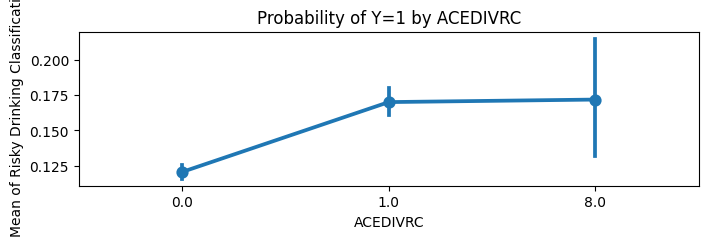

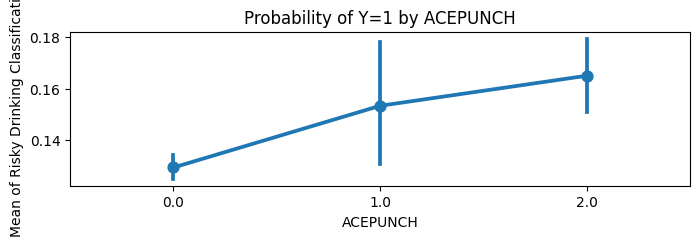

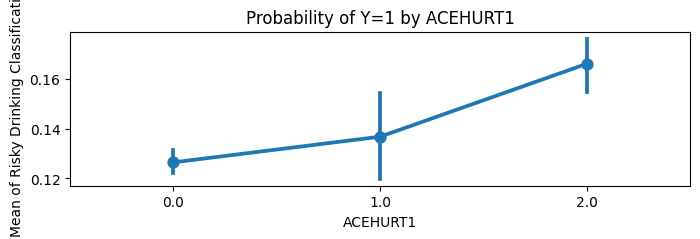

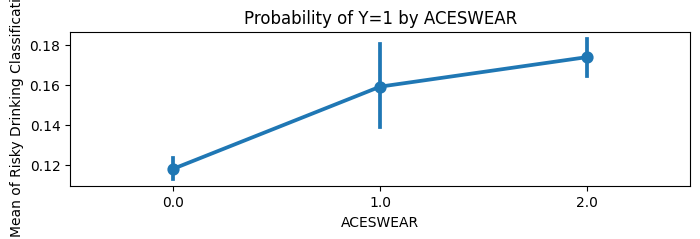

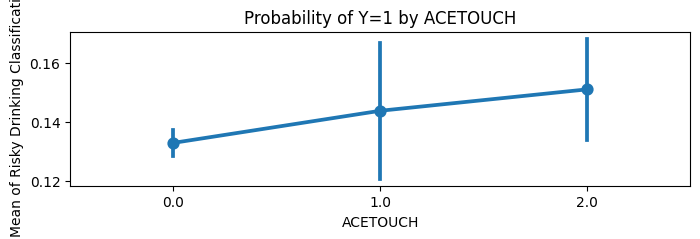

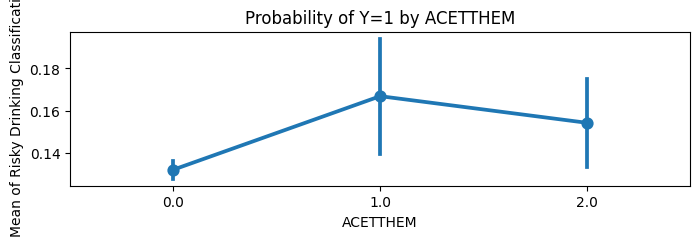

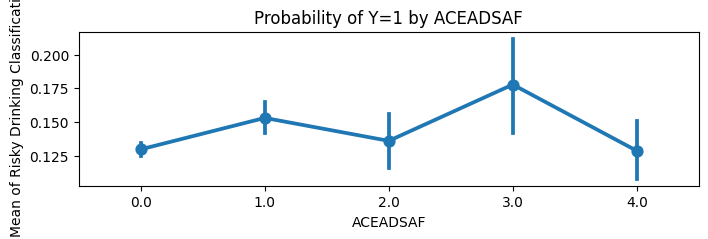

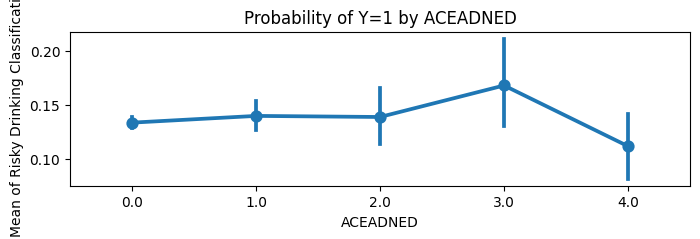

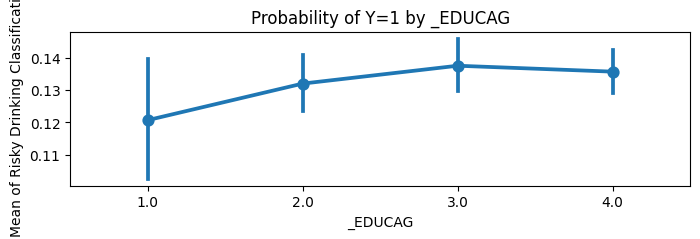

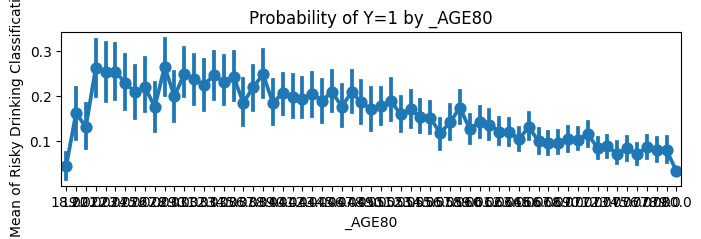

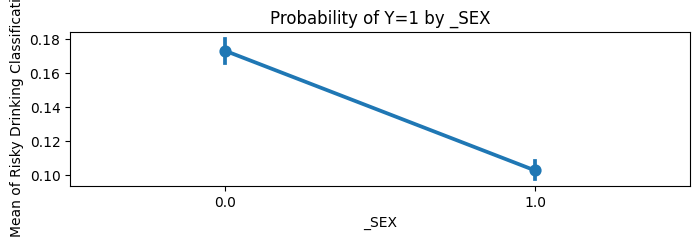

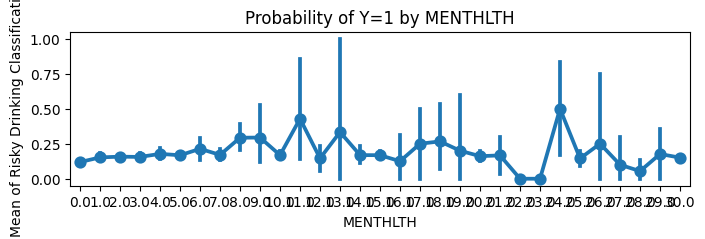

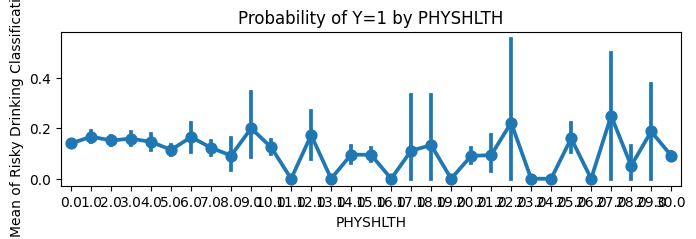

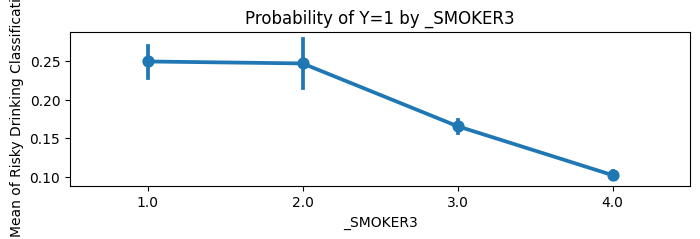

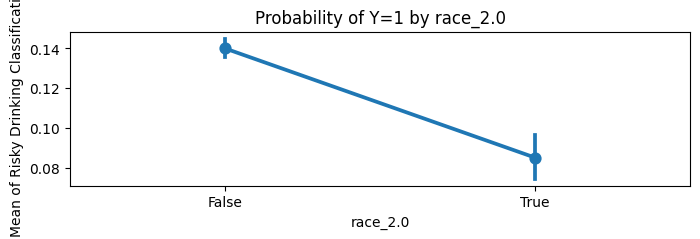

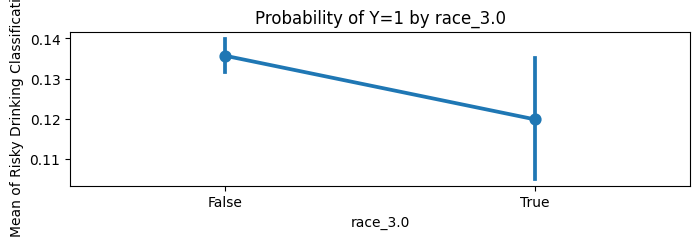

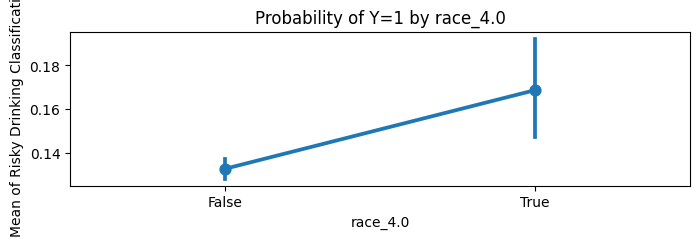

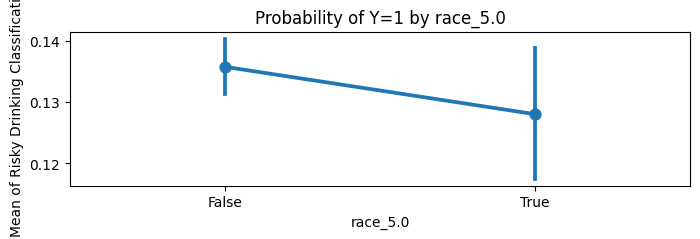

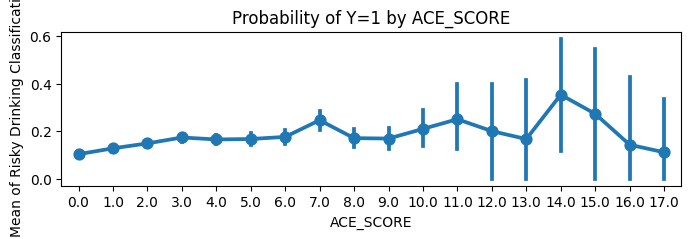

In [5]:
for col in X_train.columns:
    plt.figure(figsize=(8, 2))
    order = sorted(X_train[col].dropna().unique())
    sns.pointplot(x=X_train[col], y=Y_train['risky_drinking'], order=order)
    plt.title(f"Probability of Y=1 by {col}")
    plt.ylabel("Mean of Risky Drinking Classification")
    plt.show()